<a href="https://colab.research.google.com/github/musthak077/git_demo_remote/blob/master/Regressionprojectoncars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded=files.upload()

Saving cars.csv to cars.csv


In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set() # Setting a default seaborn setting in plots

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [3]:
df=pd.read_csv("cars.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,2
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,1
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,4
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,3
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,5


In [4]:
df.shape

(14, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       14 non-null     object 
 1   Year           14 non-null     int64  
 2   Selling_Price  14 non-null     float64
 3   Present_Price  14 non-null     float64
 4   Kms_Driven     14 non-null     int64  
 5   Fuel_Type      14 non-null     object 
 6   Seller_Type    14 non-null     object 
 7   Transmission   14 non-null     object 
 8   Owner          14 non-null     int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 1.1+ KB


In [6]:
df.isnull().mean()

,0
Car_Name,0.0
Year,0.0
Selling_Price,0.0
Present_Price,0.0
Kms_Driven,0.0
Fuel_Type,0.0
Seller_Type,0.0
Transmission,0.0
Owner,0.0


In [7]:
df.describe(include='all')

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
count,14,14.000000,14.000000,14.000000,14.000000,14,14,14,14.000000
unique,9,NaN,NaN,NaN,NaN,2,1,2,NaN
top,ciaz,NaN,NaN,NaN,NaN,Petrol,Dealer,Manual,NaN
freq,6,NaN,NaN,NaN,NaN,7,14,13,NaN
mean,NaN,2015.000000,6.057143,8.000000,23972.928571,NaN,NaN,NaN,2.928571
std,NaN,1.754116,2.074187,2.182934,16632.744306,NaN,NaN,NaN,1.439246
min,NaN,2011.000000,2.850000,3.600000,2071.000000,NaN,NaN,NaN,1.000000
25%,NaN,2014.250000,4.637500,7.080000,8925.000000,NaN,NaN,NaN,2.000000
50%,NaN,2015.000000,6.625000,8.750000,23136.500000,NaN,NaN,NaN,3.000000
75%,NaN,2015.750000,7.400000,9.757500,40132.500000,NaN,NaN,NaN,4.000000


In [8]:
df.describe(include='object')

,Car_Name,Fuel_Type,Seller_Type,Transmission
count,14,14,14,14
unique,9,2,1,2
top,ciaz,Petrol,Dealer,Manual
freq,6,7,14,13


In [9]:
print(df['Fuel_Type'].unique())
print(df['Seller_Type'].unique())
print(df['Transmission'].unique())
print(df['Owner'].unique())

['Petrol' 'Diesel']
['Dealer']
['Manual' 'Automatic']
[2 1 4 3 5]


In [10]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

/tmp/ipython-input-1475824536.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.Year)


<Axes: xlabel='Year', ylabel='Density'>

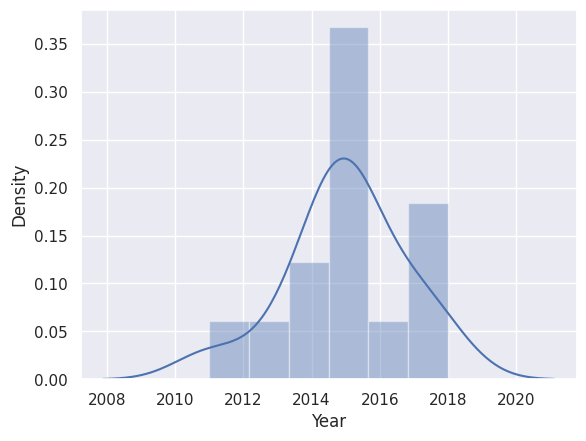

In [11]:
sns.distplot(df.Year)

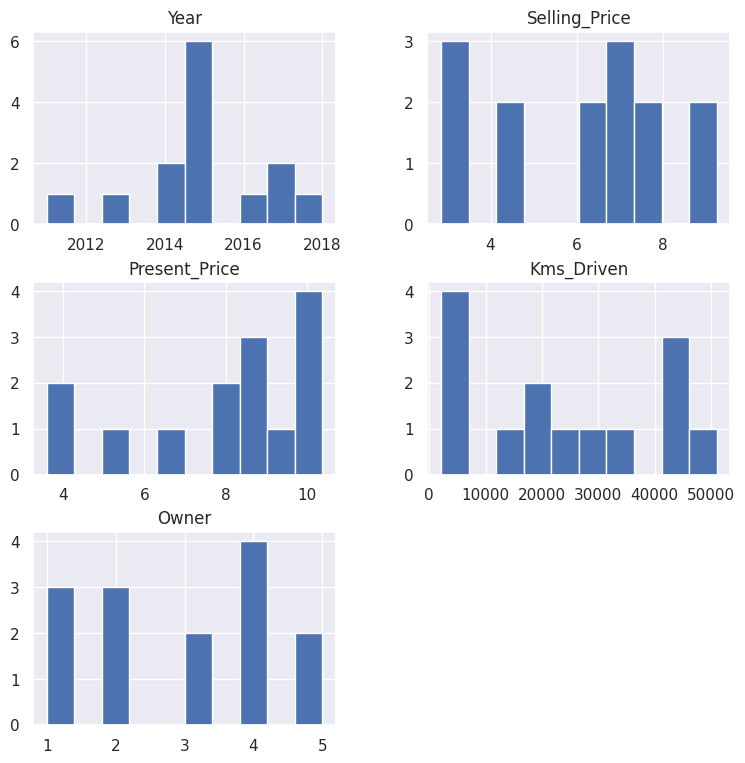

In [12]:
fig=df.hist(figsize=(9,9))

/tmp/ipython-input-2024453553.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Seller_Type', y='Selling_Price', data=df, palette='twilight')


<Axes: xlabel='Seller_Type', ylabel='Selling_Price'>

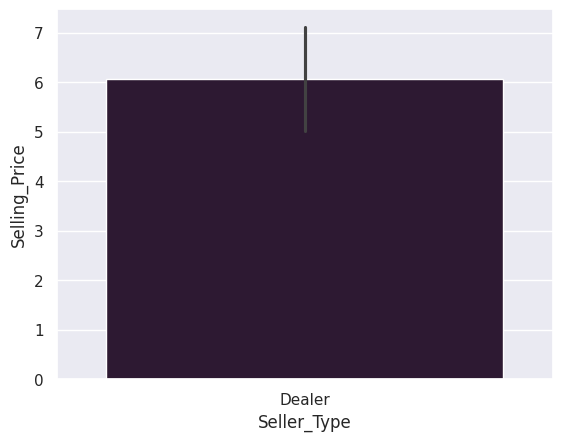

In [13]:
sns.barplot(x='Seller_Type', y='Selling_Price', data=df, palette='twilight')

/tmp/ipython-input-1832597505.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Fuel_Type',y='Selling_Price', data=df, palette='twilight')


<Axes: xlabel='Fuel_Type', ylabel='Selling_Price'>

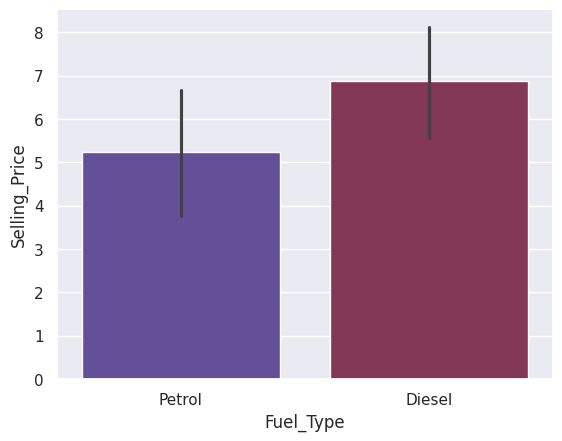

In [14]:
sns.barplot(x='Fuel_Type',y='Selling_Price', data=df, palette='twilight')

<Axes: xlabel='Selling_Price', ylabel='Year'>

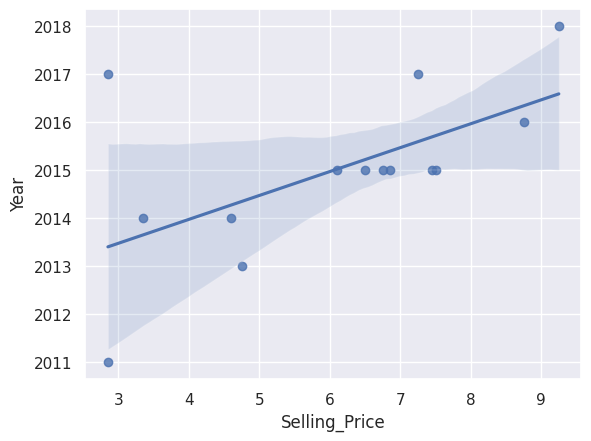

In [15]:
sns.regplot(x='Selling_Price',y='Year',data=df)

<Axes: xlabel='Selling_Price', ylabel='Kms_Driven'>

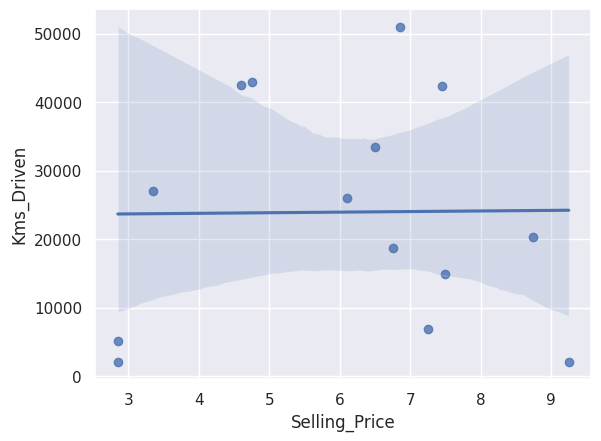

In [16]:
sns.regplot(x='Selling_Price',y='Kms_Driven',data=df)

/tmp/ipython-input-2166458764.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Transmission',y='Selling_Price', data=df, palette='spring')


<Axes: xlabel='Transmission', ylabel='Selling_Price'>

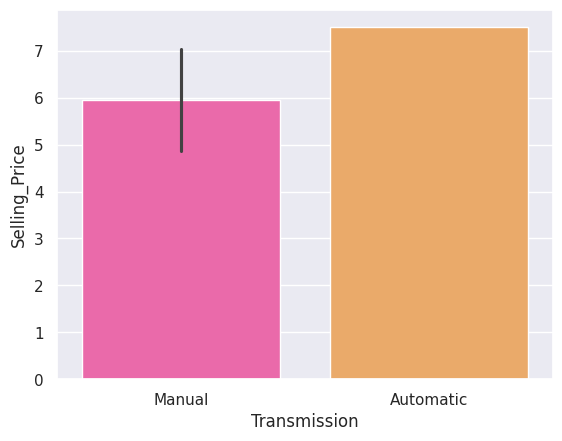

In [17]:
sns.barplot(x='Transmission',y='Selling_Price', data=df, palette='spring')

/tmp/ipython-input-2209927787.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Owner',y='Selling_Price', data=df, palette='ocean')


<Axes: xlabel='Owner', ylabel='Selling_Price'>

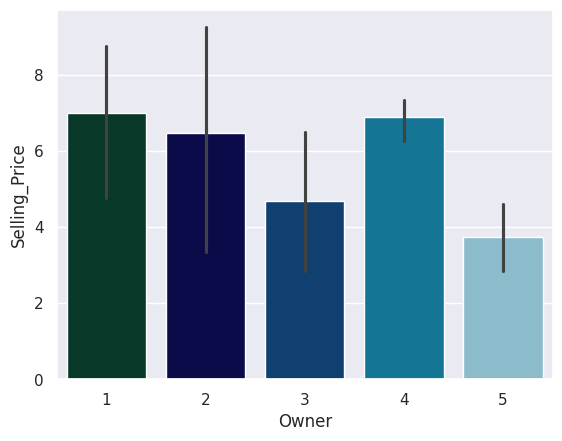

In [18]:
sns.barplot(x='Owner',y='Selling_Price', data=df, palette='ocean')

In [19]:
def plot_categorical (feature, dataset):
    ax = sns.countplot(y=feature, data=dataset)
    plt.title(f'Distribution of {feature}')
    plt.xlabel('Count')
    total = len(dataset[feature])
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_width()/total)
        x=p.get_x() + p.get_width() + 0.02
        y=p.get_y() + p.get_height()/2
        ax.annotate(percentage, (x, y))
    plt.show()

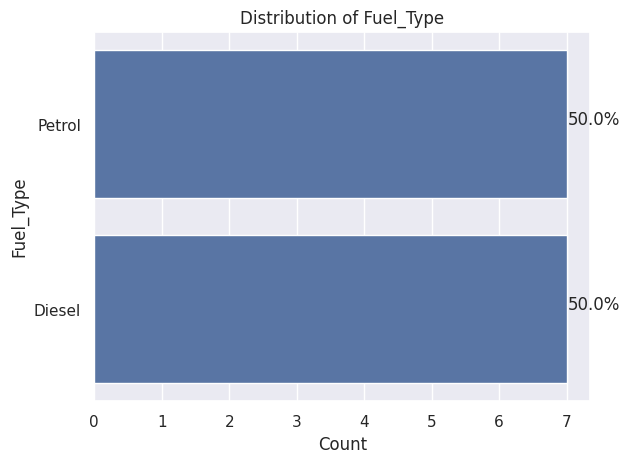

In [20]:
plot_categorical('Fuel_Type', df)

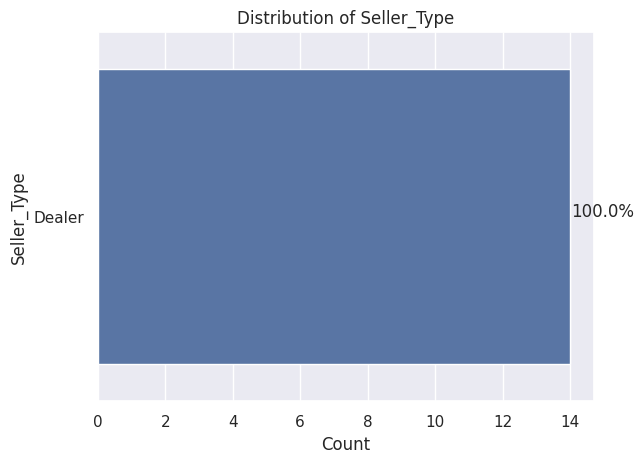

In [21]:
plot_categorical('Seller_Type', df)

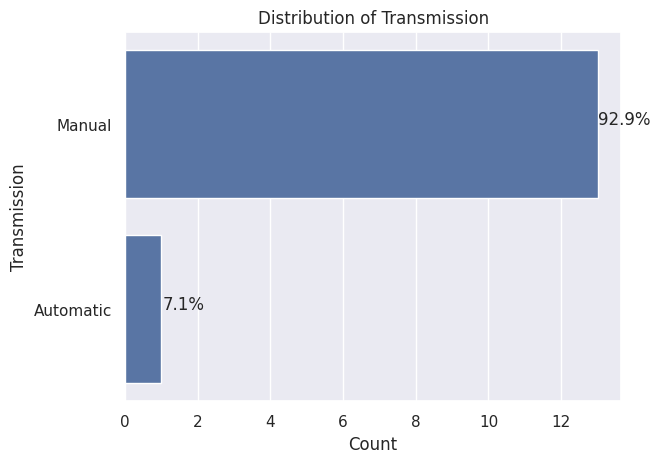

In [22]:
plot_categorical('Transmission', df)